# Study 9: Parameter Estimation (Grid Search)
current iteration: search over length_scale and mu_0

Tests whether fitting the GP `length_scale` and prior mean `mu_0` significantly improves fit\nto participant prevalence ratings, relative to a null model (large lengthscale, fitted mu_0).

`mu_0` sets the population-level baseline: P(z'=1) = sigmoid(mu_0) applies uniformly to all features.\n`length_scale` controls how far GP influence spreads across the feature embedding space.\n\nFor each `(length_scale, mu_0)` pair, runs the full pipeline:
1. Joint MCMC over `(y_train, y'_1, ..., y'_J)`
2. Beta mixture fitting → `E[p' | u, θ]` per test feature
3. Pearson r against empirical participant ratings


**Scientific question**: does feature-space proximity (lengthscale) explain variance in human\nprevalence judgments beyond a flat population baseline (mu_0)?

In [10]:
import sys, csv, pickle as pkl
sys.path.insert(0, ".")

import numpy as np
import jax
import jax.numpy as jnp
import blackjax
import matplotlib.pyplot as plt

from model_jax import (
    make_log_density_fn_joint,
    fit_beta_mixtures_all_features,
)

In [11]:
with open('../features/set2_features_dataframe.pkl', 'rb') as f:
    df = pkl.load(f)

with open('../../data/study9.csv') as f:
    rows = list(csv.reader(f))
CSV_HEADER = rows[0]
data_rows  = rows[3:]

print(f"Features: {len(df)} total, {(df.split=='train').sum()} train, {(df.split=='test').sum()} test")
print(f"Participants: {len(data_rows)}")

Features: 60 total, 45 train, 15 test
Participants: 402


In [12]:
CSV_TO_FEATURE = {
    'diet_can_eat_spicy_1':  'can eat spicy food',
    'diet_breakfast_late_1': 'eat breakfast very late',
    'diet_five_meals_day_1': 'eat five meals a day',
    'diet_like_juice_pulp_1':'like juice with pulp',
    'diet_pepper_on_all_1':  'put pepper on all their foods',
    'pers_cry_easily_1':     'cry easily',
    'pers_collect_rocks_1':  'like to collect rocks',
    'pers_like_to_dance_1':  'like to dance',
    'pers_like_highfive_1':  'like to give high-fives',
    'pers_read_books_1':     'like to read books',
    'phys_can_roll_tongue_1':'can roll their tongue',
    'phys_can_snap_toes_1':  'can snap with their toes',
    'phys_can_wiggle_ears_1':'can wiggle their ears',
    'phys_cold_hands_feet_1':'have cold hands and feet',
    'phys_snore_sleep_1':    'snore when they sleep',
}
TEST_CSV_COLS = list(CSV_TO_FEATURE.keys())
feat_idx = df.set_index('feature')

train_df = df[df.split == 'train']
x_train  = jnp.array(train_df[['x_2d', 'y_2d']].values)          # (n_train, 2)
u_train  = jnp.zeros(len(train_df), dtype=jnp.int32)              # all generic

test_feature_names = [CSV_TO_FEATURE[c] for c in TEST_CSV_COLS]
x_test = jnp.array(
    [feat_idx.loc[name, ['x_2d', 'y_2d']].values for name in test_feature_names]
)  # (J, 2)

print(f"x_train: {x_train.shape}, x_test: {x_test.shape}")

x_train: (45, 2), x_test: (15, 2)


In [13]:
col_indices = [CSV_HEADER.index(c) for c in TEST_CSV_COLS]

ratings = []
for row in data_rows:
    try:
        vals = [int(row[i]) / 100.0 for i in col_indices]
        ratings.append(vals)
    except (ValueError, IndexError):
        pass

responses = jnp.array(ratings)  # (N, J)
N, J = responses.shape
print(f"responses: {responses.shape}  (N={N} participants, J={J} features)")

empirical_mean = np.array(responses.mean(axis=0))  # (J,)

responses: (402, 15)  (N=402 participants, J=15 features)


In [14]:
LENGTH_SCALES = [0.1, 0.2, 0.4, 0.8, 1.5, 3.0, 10.0]
MU_0_VALS     = [-1.0, -0.5, 0.0, 0.5, 1.0]   # sigmoid: ~0.27, 0.38, 0.50, 0.62, 0.73

# null model: large lengthscale (features are independent), mu_0 free
# full model: best (ls, mu_0) pair

FIXED_PARAMS = {
    'output_scale': 1.5,
    'beta':         3.0,
}

print(f"Grid: {len(LENGTH_SCALES)} lengthscales × {len(MU_0_VALS)} mu_0 values = {len(LENGTH_SCALES)*len(MU_0_VALS)} runs")

Grid: 7 lengthscales × 5 mu_0 values = 35 runs


In [15]:
from itertools import product

n_warmup  = 500
n_samples = 2000
rng_np    = np.random.default_rng(0)

results = []  # one dict per (length_scale, mu_0)
total   = len(LENGTH_SCALES) * len(MU_0_VALS)

for i, (ls, mu_0) in enumerate(product(LENGTH_SCALES, MU_0_VALS)):
    print(f"[{i+1:2d}/{total}] length_scale={ls:<5}  mu_0={mu_0:<5}", end="  ")
    params = {**FIXED_PARAMS, 'length_scale': ls, 'mu_0': mu_0}

    log_density_fn = make_log_density_fn_joint(u_train, x_train, x_test, params)

    init_position = {
        'training_coherences': jnp.zeros(x_train.shape[0]),
        'test_coherences':     jnp.zeros(J),
    }

    rng_key = jax.random.PRNGKey(0)  # same seed per run for comparability
    rng_key, warmup_key = jax.random.split(rng_key)
    warmup = blackjax.window_adaptation(blackjax.nuts, log_density_fn)
    (state, nuts_params), _ = warmup.run(warmup_key, init_position, num_steps=n_warmup)

    nuts = blackjax.nuts(log_density_fn, **nuts_params)

    @jax.jit
    def one_step(state, key):
        return nuts.step(key, state)

    keys = jax.random.split(rng_key, n_samples)
    test_coherences_all = []
    for key in keys[:-1]:
        state, _ = one_step(state, key)
        test_coherences_all.append(np.array(state.position['test_coherences']))
    test_coherences_all = np.array(test_coherences_all)  # (S, J)

    pz1_samples_all = [
        np.array(jax.nn.sigmoid(jnp.array(test_coherences_all[:, j]))) for j in range(J)
    ]
    pz1_test = np.array([float(np.mean(s)) for s in pz1_samples_all])  # (J,)

    pz1_broadcast = jnp.array(
        np.stack([
            rng_np.choice(pz1_samples_all[j], size=N, replace=True)
            for j in range(J)
        ], axis=1)
    )  # (N, J)
    beta_params = fit_beta_mixtures_all_features(responses, pz1_broadcast)

    alpha_kl  = np.array(beta_params[:, 0])
    beta_kl   = np.array(beta_params[:, 1])
    alpha_nkl = np.array(beta_params[:, 2])
    beta_nkl  = np.array(beta_params[:, 3])
    mean_kl   = alpha_kl  / (alpha_kl  + beta_kl)
    mean_nkl  = alpha_nkl / (alpha_nkl + beta_nkl)
    pred_prevalence = pz1_test * mean_kl + (1 - pz1_test) * mean_nkl  # (J,)

    pearson_r = float(np.corrcoef(empirical_mean, pred_prevalence)[0, 1])
    print(f"Pearson r = {pearson_r:.3f}")

    results.append({
        'length_scale':    ls,
        'mu_0':            mu_0,
        'pz1_test':        pz1_test,
        'pred_prevalence': pred_prevalence,
        'pearson_r':       pearson_r,
    })

print("\nGrid search complete.")

[ 1/35] length_scale=0.1    mu_0=-1.0   Pearson r = 0.937
[ 2/35] length_scale=0.1    mu_0=-0.5   Pearson r = 0.941
[ 3/35] length_scale=0.1    mu_0=0.0    Pearson r = 0.901
[ 4/35] length_scale=0.1    mu_0=0.5    Pearson r = 0.958
[ 5/35] length_scale=0.1    mu_0=1.0    Pearson r = 0.644
[ 6/35] length_scale=0.2    mu_0=-1.0   Pearson r = 0.933
[ 7/35] length_scale=0.2    mu_0=-0.5   Pearson r = 0.922
[ 8/35] length_scale=0.2    mu_0=0.0    Pearson r = 0.935
[ 9/35] length_scale=0.2    mu_0=0.5    

/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/scipy/_lib/array_api_compat/numpy/_aliases.py:106: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype=dtype, copy=copy)


Pearson r = 0.899
[10/35] length_scale=0.2    mu_0=1.0    Pearson r = 0.914
[11/35] length_scale=0.4    mu_0=-1.0   

/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/scipy/_lib/array_api_compat/numpy/_aliases.py:106: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype=dtype, copy=copy)
/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/scipy/_lib/array_api_compat/numpy/_aliases.py:106: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype=dtype, copy=copy)


Pearson r = 0.898
[12/35] length_scale=0.4    mu_0=-0.5   Pearson r = 0.929
[13/35] length_scale=0.4    mu_0=0.0    Pearson r = 0.871
[14/35] length_scale=0.4    mu_0=0.5    Pearson r = 0.889
[15/35] length_scale=0.4    mu_0=1.0    

...

Pearson r = 0.912
[19/35] length_scale=0.8    mu_0=0.5    Pearson r = 0.911
[20/35] length_scale=0.8    mu_0=1.0    Pearson r = 0.701
[21/35] length_scale=1.5    mu_0=-1.0   Pearson r = 0.936
[22/35] length_scale=1.5    mu_0=-0.5   Pearson r = 0.918
[23/35] length_scale=1.5    mu_0=0.0    Pearson r = 0.933
[24/35] length_scale=1.5    mu_0=0.5    

/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/scipy/_lib/array_api_compat/numpy/_aliases.py:106: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype=dtype, copy=copy)


Pearson r = 0.889
[25/35] length_scale=1.5    mu_0=1.0    Pearson r = 0.844
[26/35] length_scale=3.0    mu_0=-1.0   Pearson r = 0.908
[27/35] length_scale=3.0    mu_0=-0.5   Pearson r = 0.892
[28/35] length_scale=3.0    mu_0=0.0    Pearson r = 0.923
[29/35] length_scale=3.0    mu_0=0.5    

/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/scipy/_lib/array_api_compat/numpy/_aliases.py:106: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype=dtype, copy=copy)


Pearson r = 0.894
[30/35] length_scale=3.0    mu_0=1.0    Pearson r = 0.885
[31/35] length_scale=10.0   mu_0=-1.0   Pearson r = 0.945
[32/35] length_scale=10.0   mu_0=-0.5   Pearson r = 0.919
[33/35] length_scale=10.0   mu_0=0.0    Pearson r = 0.930
[34/35] length_scale=10.0   mu_0=0.5    Pearson r = 0.952
[35/35] length_scale=10.0   mu_0=1.0    Pearson r = 0.943

Grid search complete.


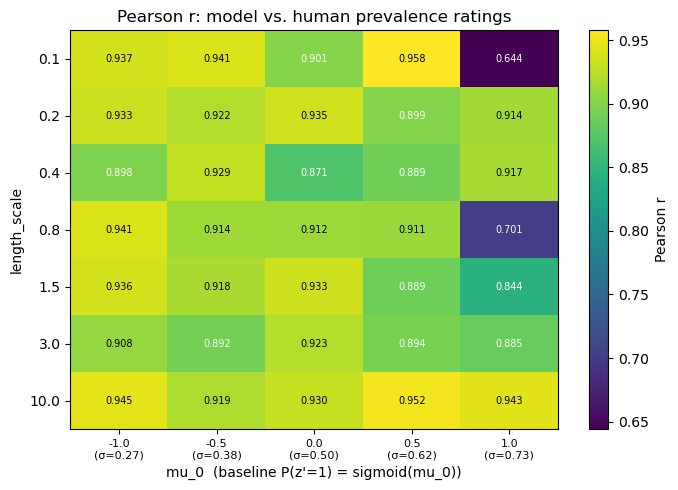

Best:  length_scale=0.1,  mu_0=0.5,  Pearson r=0.958
Null:  length_scale=10.0, mu_0=0.5, Pearson r=0.952


In [16]:
# Heatmap: Pearson r over (length_scale, mu_0) grid
r_grid = np.array([res['pearson_r'] for res in results]).reshape(len(LENGTH_SCALES), len(MU_0_VALS))

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(r_grid, aspect='auto', cmap='viridis',
               vmin=r_grid.min(), vmax=r_grid.max())
ax.set_xticks(range(len(MU_0_VALS)))
ax.set_xticklabels([f"{m}\n(σ={1/(1+np.exp(-m)):.2f})" for m in MU_0_VALS], fontsize=8)
ax.set_yticks(range(len(LENGTH_SCALES)))
ax.set_yticklabels(LENGTH_SCALES)
ax.set_xlabel('mu_0  (baseline P(z\'=1) = sigmoid(mu_0))')
ax.set_ylabel('length_scale')
ax.set_title('Pearson r: model vs. human prevalence ratings')
plt.colorbar(im, ax=ax, label='Pearson r')

# annotate each cell
for i in range(len(LENGTH_SCALES)):
    for j in range(len(MU_0_VALS)):
        ax.text(j, i, f"{r_grid[i, j]:.3f}", ha='center', va='center',
                fontsize=7, color='white' if r_grid[i, j] < r_grid.mean() else 'black')

plt.tight_layout()
plt.show()

best = max(results, key=lambda r: r['pearson_r'])
# null: largest lengthscale, best mu_0 among ls=10 runs
null_results = [r for r in results if r['length_scale'] == LENGTH_SCALES[-1]]
null_best    = max(null_results, key=lambda r: r['pearson_r'])
print(f"Best:  length_scale={best['length_scale']},  mu_0={best['mu_0']},  Pearson r={best['pearson_r']:.3f}")
print(f"Null:  length_scale={null_best['length_scale']}, mu_0={null_best['mu_0']}, Pearson r={null_best['pearson_r']:.3f}")

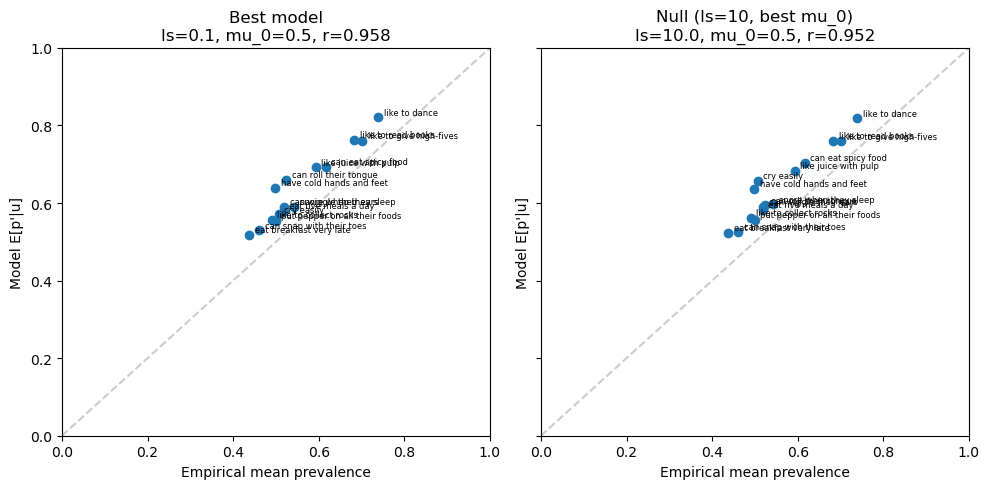

In [17]:
# Scatter plots for best and null models side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True, sharex=True)
lims = [0, 1]

for ax, res, label in zip(axes, [best, null_best], ['Best model', 'Null (ls=10, best mu_0)']):
    ax.scatter(empirical_mean, res['pred_prevalence'], zorder=3)
    for j, name in enumerate(test_feature_names):
        ax.annotate(name, (empirical_mean[j], res['pred_prevalence'][j]),
                    fontsize=6, xytext=(4, 2), textcoords='offset points')
    ax.plot(lims, lims, '--', color='gray', alpha=0.4)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Empirical mean prevalence')
    ax.set_ylabel("Model E[p'|u]")
    ax.set_title(f"{label}\nls={res['length_scale']}, mu_0={res['mu_0']}, r={res['pearson_r']:.3f}")

plt.tight_layout()
plt.show()